In [1]:
from mds import rdmds
from matplotlib import pyplot as plt
from matplotlib import cm
import numpy as np


In [2]:
Simulation_Name = 'Test1_1x32x32'

d2r = np.pi/180

fxc = '../' + Simulation_Name + '/XC'
fyc = '../' + Simulation_Name + '/YC'
frc = '../' + Simulation_Name + '/RC'
fdxc = '../' + Simulation_Name + '/DXC'
fdyc = '../' + Simulation_Name + '/DYC'

XC = rdmds(fxc)
YC = rdmds(fyc)
RC = rdmds(frc)

nx = XC.shape[1]
ny = XC.shape[0]
nz = RC.shape[0]

print(nx,ny,nz)

xc0 = XC[0,:].ravel()
yc0 = YC[:,0].ravel()
zc0 = np.squeeze(RC)

dz = zc0[0]-zc0[1]

print(nx,ny,nz,dz,xc0.shape,yc0.shape,zc0.shape)

1 32 32
1 32 32 37.5 (1,) (32,) (32,)


In [3]:
timesnap = 7500

fdataf = '../' + Simulation_Name + '/Diag_field'
dataf = rdmds(fdataf,timesnap)

print(dataf.shape)

fdatah = '../' + Simulation_Name + '/Diag_heat'
datah = rdmds(fdatah,timesnap)

print(datah.shape)

(5, 32, 32, 1)
(5, 32, 32, 1)


In [4]:
U = dataf[0,:,:,:]
V = dataf[1,:,:,:]
W = dataf[2,:,:,:]
T = dataf[3,:,:,:]
RHO = dataf[4,:,:,:]

Advy = datah[0,:,:,:]/dz**2
Advz = datah[1,:,:,:]/dz**2
Dify = datah[2,:,:,:]/dz**2
Difz = datah[3,:,:,:]/dz**2
Difzi = datah[4,:,:,:]/dz**2

print(np.max(np.abs(Advy)))
print(np.max(np.abs(Advz)))
print(np.max(np.abs(Dify)))
print(np.max(np.abs(Difz)))
print(np.max(np.abs(Difzi)))

0.0
0.0
2.0791757590312955e-16
0.0
4.273780208333333


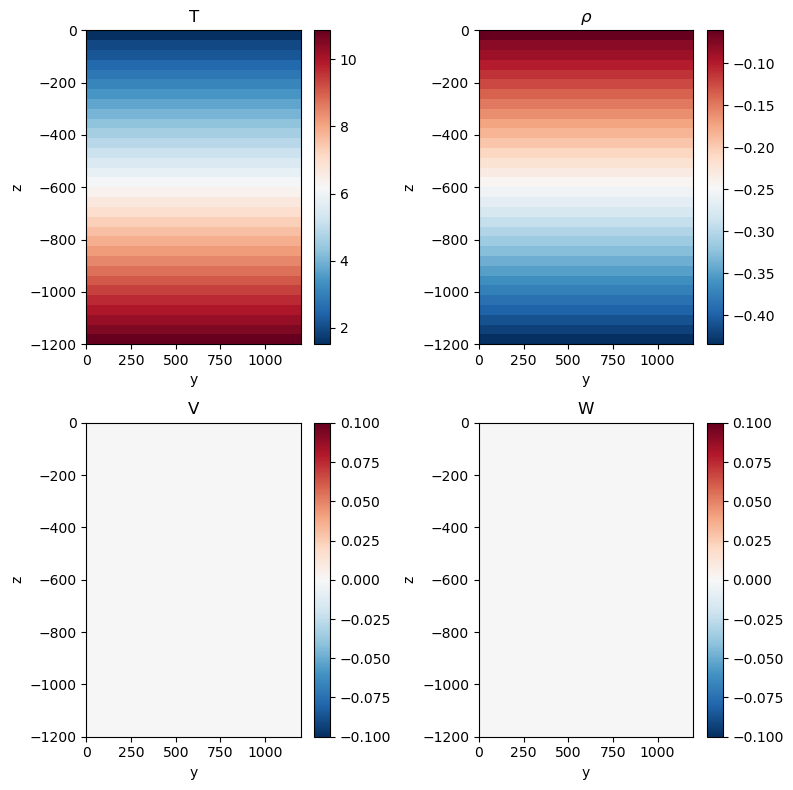

In [5]:
# Plot the y-z flow and temperature fields

plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.pcolormesh(yc0,zc0,T[:,:,int(nx/2)],cmap='RdBu_r')
plt.colorbar()
plt.xlabel('y')
plt.ylabel('z')
plt.title('T')

plt.subplot(2,2,2)
plt.pcolormesh(yc0,zc0,RHO[:,:,int(nx/2)],cmap='RdBu_r')
plt.colorbar()
plt.xlabel('y')
plt.ylabel('z')
plt.title(r'$\rho$')

plt.subplot(2,2,3)
plt.pcolormesh(yc0,zc0,V[:,:,int(nx/2)],cmap='RdBu_r')
plt.colorbar()
plt.xlabel('y')
plt.ylabel('z')
plt.title('V')

plt.subplot(2,2,4)
plt.pcolormesh(yc0,zc0,W[:,:,int(nx/2)],cmap='RdBu_r')
plt.colorbar()
plt.xlabel('y')
plt.ylabel('z')
plt.title('W')

plt.tight_layout()


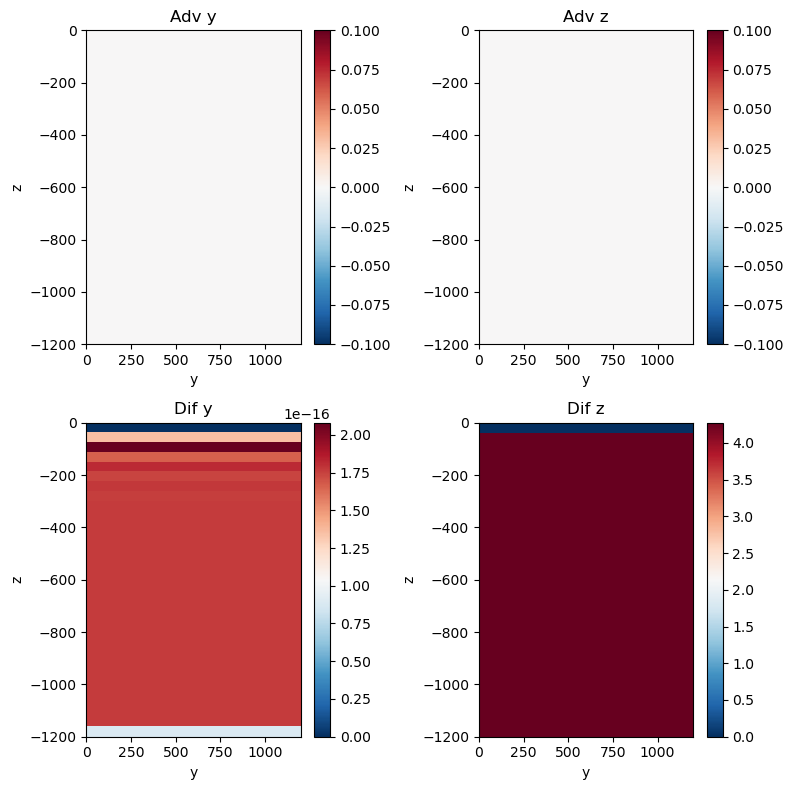

In [6]:
# Plot the y-z heat flux fields

plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.pcolor(yc0,zc0,Advy[:,:,int(nx/2)],cmap='RdBu_r')
plt.colorbar()
plt.xlabel('y')
plt.ylabel('z')
plt.title('Adv y')

plt.subplot(2,2,2)
plt.pcolormesh(yc0,zc0,Advz[:,:,int(nx/2)],cmap='RdBu_r')
plt.colorbar()
plt.xlabel('y')
plt.ylabel('z')
plt.title('Adv z')

plt.subplot(2,2,3)
plt.pcolor(yc0,zc0,Dify[:,:,int(nx/2)],cmap='RdBu_r')
plt.colorbar()
plt.xlabel('y')
plt.ylabel('z')
plt.title('Dif y')

plt.subplot(2,2,4)
plt.pcolormesh(yc0,zc0,Difzi[:,:,int(nx/2)],cmap='RdBu_r')
plt.colorbar()
plt.xlabel('y')
plt.ylabel('z')
plt.title('Dif z')

plt.tight_layout()


In [7]:
Qyadv = np.mean(Advy)
Qzadv = np.mean(Advz)
Qydif = np.mean(Dify)
Qzdif = np.mean(Difz+Difzi)

print('Global mean heat flux: Adv y = %.3e, Adv z = %.3e, Dif y = %.3e, Dif z = %.3e'%(Qyadv,Qzadv,Qydif,Qzdif))

Global mean heat flux: Adv y = 0.000e+00, Adv z = 0.000e+00, Dif y = 1.676e-16, Dif z = 4.140e+00


548.0512893343735 4.4059316768123695


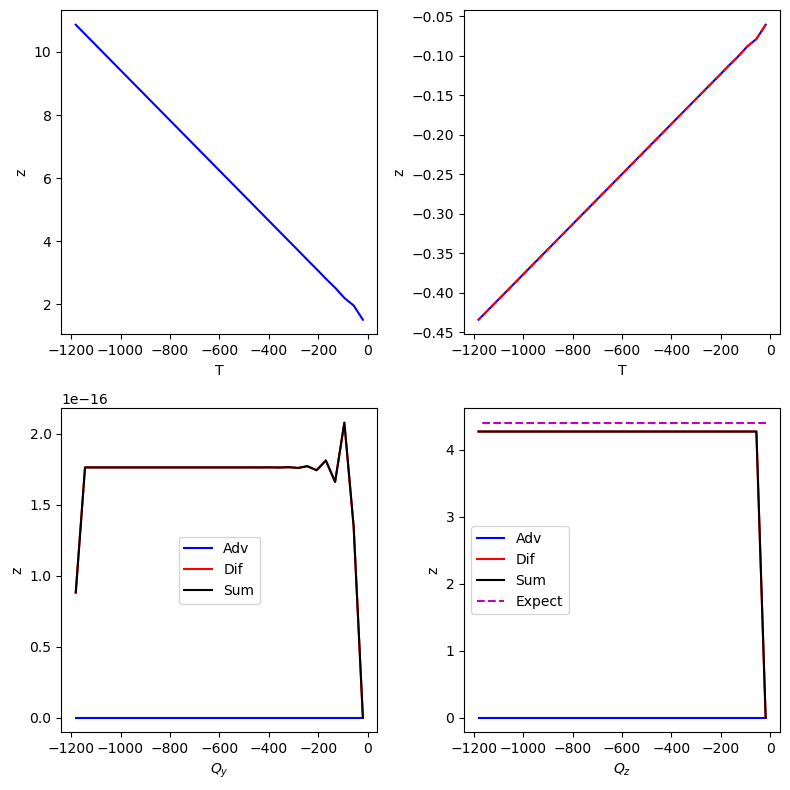

In [11]:
# Horizontal-mean temperature profile

Tzm = np.mean(T,axis=(1,2))
rhozm = np.mean(RHO,axis=(1,2))
dTdz = (Tzm[0]-Tzm[-1])/(zc0[0]-zc0[-1])
alpha = 4e-5
g = 0.1
bn = -alpha*g*dTdz
f = 2*2*np.pi/125663.7
rho0=1000
H0 = dz*nz
Kn = 0.66 * bn**(3/2)*f**(-2)*H0**2
Qzest = -Kn*dTdz
print(Kn,Qzest)

plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.plot(zc0,Tzm,'-b')
plt.xlabel('T')
plt.ylabel('z')

plt.subplot(2,2,2)
plt.plot(zc0,rhozm,'-b')
plt.plot(zc0,-alpha*Tzm*rho0,'--r')
plt.xlabel('T')
plt.ylabel('z')

plt.subplot(2,2,3)
plt.plot(zc0,np.mean(Advy,axis=(1,2)),'-b',label='Adv')
plt.plot(zc0,np.mean(Dify,axis=(1,2)),'-r',label='Dif')
plt.plot(zc0,np.mean(Dify,axis=(1,2))+np.mean(Advy,axis=(1,2)),'-k',label='Sum')
plt.xlabel('$Q_y$')
plt.ylabel('z')
plt.legend()

plt.subplot(2,2,4)
plt.plot(zc0,np.mean(Advz,axis=(1,2)),'-b',label='Adv')
plt.plot(zc0,np.mean(Difzi,axis=(1,2)),'-r',label='Dif')
plt.plot(zc0,np.mean(Difzi,axis=(1,2))+np.mean(Advz,axis=(1,2)),'-k',label='Sum')
plt.plot(zc0,zc0*0+Qzest,'--m',label='Expect')
plt.xlabel('$Q_z$')
plt.ylabel('z')
plt.legend()


plt.tight_layout()


In [10]:
print(Difzi[:,3,0])

[0.         4.27378021 4.27378021 4.27378021 4.27378021 4.27378021
 4.27378021 4.27378021 4.27378021 4.27378021 4.27378021 4.27378021
 4.27378021 4.27378021 4.27378021 4.27378021 4.27378021 4.27378021
 4.27378021 4.27378021 4.27378021 4.27378021 4.27378021 4.27378021
 4.27378021 4.27378021 4.27378021 4.27378021 4.27378021 4.27378021
 4.27378021 4.27378021]
